In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
data = pd.read_csv('/content/English Review (Foodpanda) - Form Responses.csv')

data.head()


,Timestamp,Sentence,Sentiment
0,9/16/2023 17:15:35,"Good, but not good like other average day.",Neutral
1,9/16/2023 17:16:06,"Ordered Naga, they didn’t even put a green chi...",Negative
2,9/16/2023 17:16:41,The food was decent but the amount of chicken ...,Neutral
3,9/16/2023 17:17:18,"Too much oil all over the Meat Lover’s Pasta, ...",Negative
4,9/16/2023 17:18:12,didn't provide any cutlery -packaging was very...,Negative


In [ ]:
# Checking for missing values in the dataset
missing_values = data.isnull().sum()
missing_values


Timestamp    0
Sentence     0
Sentiment    0
dtype: int64

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#cleaning text data using re

def preprocess_text(text):

    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [ ]:
data['Processed_Sentence'] = data['Sentence'].apply(preprocess_text)
data[['Sentence', 'Processed_Sentence', 'Sentiment']].head()

,Sentence,Processed_Sentence,Sentiment
0,"Good, but not good like other average day.",good good like average day,Neutral
1,"Ordered Naga, they didn’t even put a green chi...",ordered naga didnt even put green chilly chowmein,Negative
2,The food was decent but the amount of chicken ...,food decent amount chicken wasnt satisfactory,Neutral
3,"Too much oil all over the Meat Lover’s Pasta, ...",much oil meat lover pasta enough make anyone f...,Negative
4,didn't provide any cutlery -packaging was very...,didnt provide cutlery packaging bad,Negative


In [ ]:
data.head()

,Timestamp,Sentence,Sentiment,Processed_Sentence
0,9/16/2023 17:15:35,"Good, but not good like other average day.",Neutral,good good like average day
1,9/16/2023 17:16:06,"Ordered Naga, they didn’t even put a green chi...",Negative,ordered naga didnt even put green chilly chowmein
2,9/16/2023 17:16:41,The food was decent but the amount of chicken ...,Neutral,food decent amount chicken wasnt satisfactory
3,9/16/2023 17:17:18,"Too much oil all over the Meat Lover’s Pasta, ...",Negative,much oil meat lover pasta enough make anyone f...
4,9/16/2023 17:18:12,didn't provide any cutlery -packaging was very...,Negative,didnt provide cutlery packaging bad


In [ ]:
#non alphabetic character reemove

def preprocess_text_modified(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return ' '.join(tokens)

In [ ]:
data['Processed_Sentence'] = data['Sentence'].apply(preprocess_text_modified)
data[['Sentence', 'Processed_Sentence', 'Sentiment']].head()

,Sentence,Processed_Sentence,Sentiment
0,"Good, but not good like other average day.",good but not good like other average day,Neutral
1,"Ordered Naga, they didn’t even put a green chi...",ordered naga they didnt even put a green chill...,Negative
2,The food was decent but the amount of chicken ...,the food was decent but the amount of chicken ...,Neutral
3,"Too much oil all over the Meat Lover’s Pasta, ...",too much oil all over the meat lovers pasta mo...,Negative
4,didn't provide any cutlery -packaging was very...,didnt provide any cutlery packaging was very bad,Negative


In [ ]:
# For Word Cloud
sentiment_distribution = data['Sentiment'].value_counts()

negative_reviews = ' '.join(data[data['Sentiment'] == 'Negative']['Processed_Sentence'])
neutral_reviews = ' '.join(data[data['Sentiment'] == 'Neutral']['Processed_Sentence'])
positive_reviews = ' '.join(data[data['Sentiment'] == 'Positive']['Processed_Sentence'])

# Generating word clouds
wordcloud_neg = WordCloud(width = 800, height = 800,
                          background_color ='white',
                          min_font_size = 10).generate(negative_reviews)

wordcloud_neu = WordCloud(width = 800, height = 800,
                          background_color ='white',
                          min_font_size = 10).generate(neutral_reviews)

wordcloud_pos = WordCloud(width = 800, height = 800,
                          background_color ='white',
                          min_font_size = 10).generate(positive_reviews)



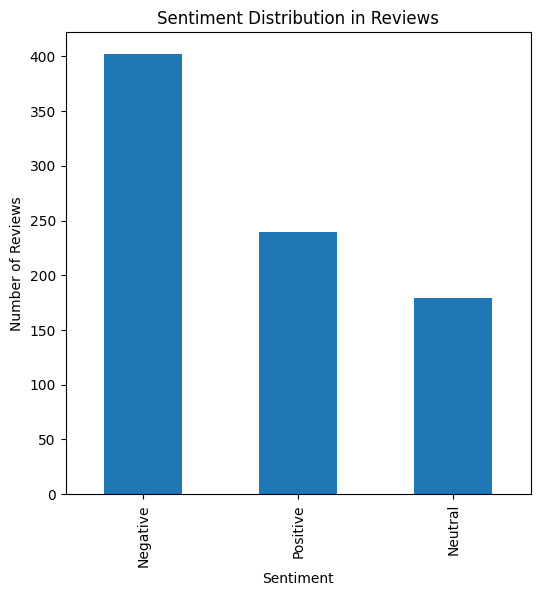

In [ ]:
# Plotting the sentiment distribution
plt.figure(figsize=(6, 6))
sentiment_distribution.plot(kind='bar')
plt.title('Sentiment Distribution in Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

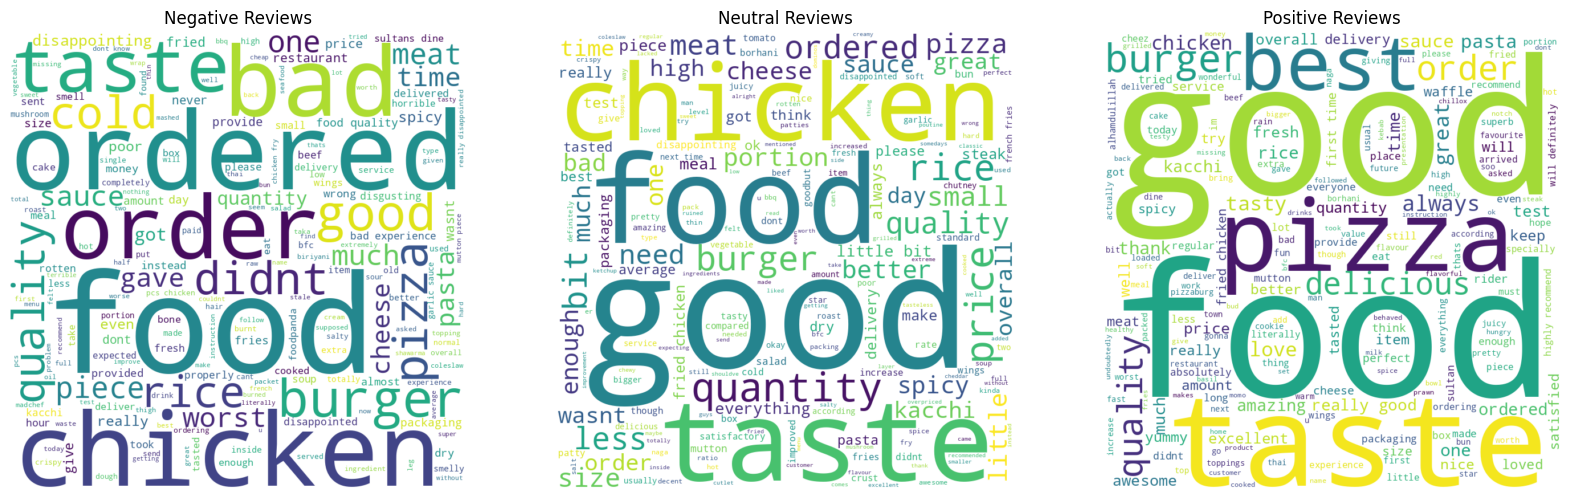

In [ ]:
# Displaying word clouds for each sentiment
plt.figure(figsize=(20, 20))

plt.subplot(1, 3, 1)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Negative Reviews')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.title('Neutral Reviews')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Positive Reviews')
plt.axis('off')

plt.show()

In [ ]:
# Data Splitting

# Vectorization using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['Processed_Sentence'])
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((656, 1866), (165, 1866), (656,), (165,))

In [ ]:
#Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

accuracy

0.6545454545454545

In [ ]:
# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)


accuracy_rf = accuracy_score(y_test, y_pred_rf)
classification_rep_rf = classification_report(y_test, y_pred_rf)

accuracy_rf


0.6484848484848484

In [ ]:
#Support Vector Machine
svm_model = SVC()
svm_model.fit(X_train, y_train)


y_pred_svm = svm_model.predict(X_test)


accuracy_svm = accuracy_score(y_test, y_pred_svm)
classification_rep_svm = classification_report(y_test, y_pred_svm)

accuracy_svm

0.6484848484848484